<a href="https://colab.research.google.com/github/demsaid400-cpu/DI-BOOTCAMP/blob/main/Week4/Day5/Exercices/Mini_Projet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df = pd.read_csv("/content/heart_disease_uci.csv")
display(df.head())

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [ ]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [ ]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


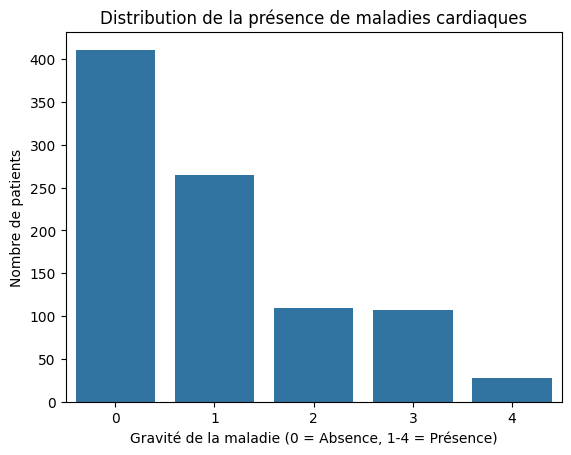

In [ ]:
sns.countplot(x="num", data=df)
plt.title("Distribution de la présence de maladies cardiaques")
plt.xlabel("Gravité de la maladie (0 = Absence, 1-4 = Présence)")
plt.ylabel("Nombre de patients")
plt.show()

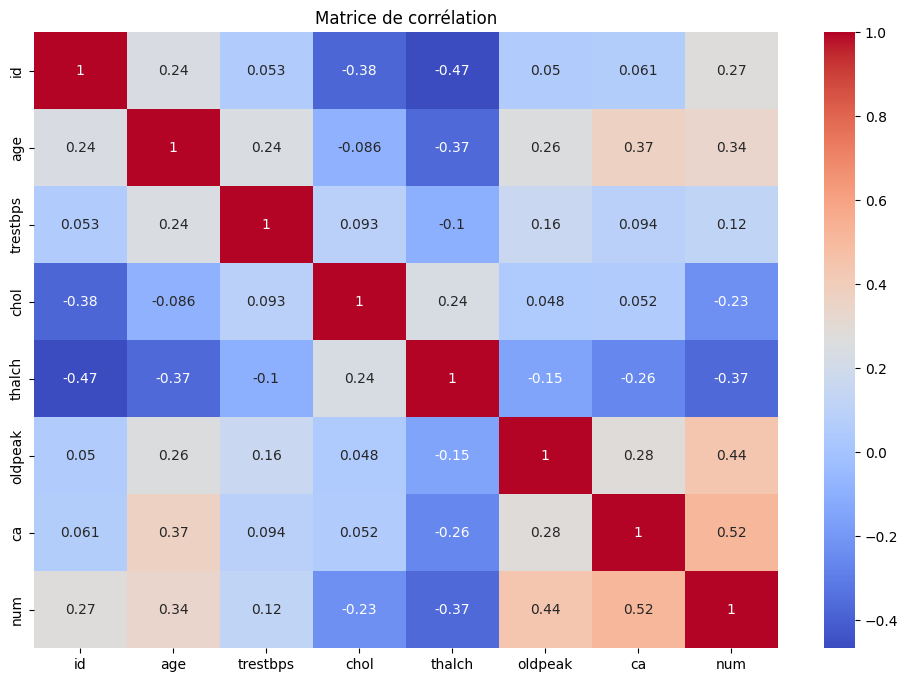

In [ ]:
plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Matrice de corrélation")
plt.show()

In [ ]:
# Création de la variable cible binaire
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

# Maintenant nous pouvons séparer les données
X = df.drop(["target", "num"], axis=1)
y = df["target"]

In [ ]:
numeric_cols = X.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy="mean")

X[numeric_cols] = imputer.fit_transform(X[numeric_cols])

In [ ]:
categorical_cols = X.select_dtypes(exclude=np.number).columns

cat_imputer = SimpleImputer(strategy="most_frequent")

X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8641304347826086


In [ ]:
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Precision : 0.8666666666666667
Recall : 0.8921568627450981
F1 Score : 0.8792270531400966


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.83      0.84        82
           1       0.87      0.89      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



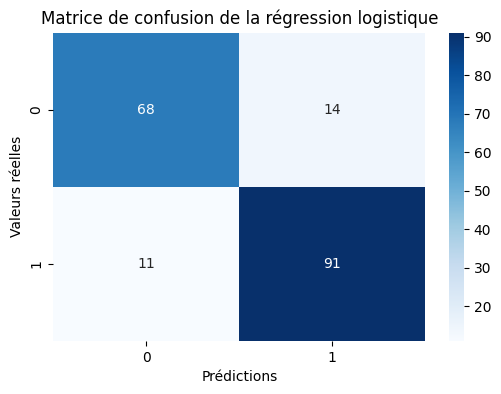

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.title("Matrice de confusion de la régression logistique")

plt.show()

Conclusion :

Ce projet a construit un modèle de régression logistique permettant de prédire la présence d’une maladie cardiaque à partir de données médicales.

Améliorations apportées après les retours d’évaluation :

* Suppression de la fuite de données en retirant la colonne num, qui contenait directement l’information utilisée pour créer la cible.
* Gestion rigoureuse des valeurs manquantes avec SimpleImputer.
* Traitement séparé des variables numériques et catégorielles.
* Encodage des variables catégorielles avec get_dummies.
* Division stratifiée des données pour préserver l’équilibre des classes.
* Mise à l’échelle des caractéristiques avant l’entraînement du modèle.
* Documentation améliorée grâce à une organisation claire du notebook.